## 1. Load Dataset and Basic Understanding

First, we load the customer churn dataset and perform basic checks
to understand its structure, size, columns, data types, and
statistical summary.

This helps us understand the dataset before performing cleaning
and preprocessing.

In [1]:
import pandas as pd

df = pd.read_csv(r"C:\Calibo\Phase-2\ML\Supervised\Business Use case\Supervised_Learning_Messy_Customer_Churn.csv")

df.head()

,Customer_ID,Age,Annual_Income,Tenure_Months,Monthly_Charges,Support_Calls_Last_3M,Data_Usage_GB,Satisfaction_Score,Contract_Type,Payment_Method,Region,Plan_Type,Churn
0,CUST-1020,22.0,23800.0,11.0,62.96,7.0,20.4,5.0,MONTHLY,Bank Transfer,North,Standard,Yes
1,CUST-1043,35.0,69400.0,17.0,75.63,6.0,17.5,9.0,Monthly,Bank Transfer,South,Basic,Yes
2,CUST-1157,55.0,NaN,49.0,92.85,3.0,21.6,1.0,Monthly,UPI,West,Basic,Yes
3,CUST-1112,36.0,80000.0,9.0,85.67,0.0,34.3,9.0,Monthly,UPI,South,Standard,Yes
4,CUST-1149,41.0,95700.0,51.0,60.77,1.0,23.7,9.0,Monthly,Debit Card,West,Premium,Yes


In [2]:
df.tail()

,Customer_ID,Age,Annual_Income,Tenure_Months,Monthly_Charges,Support_Calls_Last_3M,Data_Usage_GB,Satisfaction_Score,Contract_Type,Payment_Method,Region,Plan_Type,Churn
179,CUST-1107,55.0,54100.0,68.0,99.59,6.0,21.5,8.0,1 Year,Bank Transfer,East,Basic,Yes
180,CUST-1015,19.0,63000.0,NaN,64.24,1.0,13.0,7.0,Monthly,Credit Card,south,Premium,Yes
181,CUST-1093,29.0,45300.0,69.0,67.48,1.0,10.6,6.0,Monthly,Debit Card,East,Standard,No
182,CUST-1180,63.0,47100.0,45.0,65.58,0.0,11.3,1.0,Monthly,UPI,East,Standard,Yes
183,CUST-1103,NaN,48300.0,13.0,94.69,0.0,16.8,1.0,2 Year,Bank Transfer,West,Standard,No


## Step 3: Check Dataset Information

We use `info()` to check the number of rows, columns, data types,
and missing values in each column.

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 184 entries, 0 to 183
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Customer_ID            184 non-null    object 
 1   Age                    176 non-null    float64
 2   Annual_Income          173 non-null    object 
 3   Tenure_Months          177 non-null    float64
 4   Monthly_Charges        178 non-null    float64
 5   Support_Calls_Last_3M  179 non-null    float64
 6   Data_Usage_GB          178 non-null    float64
 7   Satisfaction_Score     178 non-null    float64
 8   Contract_Type          184 non-null    object 
 9   Payment_Method         184 non-null    object 
 10  Region                 184 non-null    object 
 11  Plan_Type              184 non-null    object 
 12  Churn                  184 non-null    object 
dtypes: float64(6), object(7)
memory usage: 18.8+ KB


## Step 4: Check Dataset Shape

We use `shape` to find the number of rows and columns
present in the dataset.

In [4]:
df.shape

(184, 13)

## Step 5: Statistical Summary

We use `describe()` to get basic statistical information
about the numerical columns, such as count, mean, standard
deviation, minimum, maximum, and quartile values.

In [5]:
df.describe()

,Age,Tenure_Months,Monthly_Charges,Support_Calls_Last_3M,Data_Usage_GB,Satisfaction_Score
count,176.000000,177.000000,178.000000,179.000000,178.000000,178.000000
mean,36.164773,39.395480,80.205899,3.217877,17.806180,5.803371
std,12.865951,21.545185,74.179370,2.577455,9.245516,2.947869
min,-5.000000,1.000000,0.000000,0.000000,-10.000000,1.000000
25%,29.000000,25.000000,57.885000,2.000000,11.600000,4.000000
50%,36.000000,38.000000,73.565000,3.000000,18.200000,6.000000
75%,41.000000,55.000000,90.280000,4.000000,24.200000,8.000000
max,145.000000,150.000000,999.000000,30.000000,44.000000,15.000000


## Step 6: Check Column Names

We check all column names to understand the features available
in the dataset and identify numerical and categorical columns.

In [6]:
df.columns

Index(['Customer_ID', 'Age', 'Annual_Income', 'Tenure_Months',
       'Monthly_Charges', 'Support_Calls_Last_3M', 'Data_Usage_GB',
       'Satisfaction_Score', 'Contract_Type', 'Payment_Method', 'Region',
       'Plan_Type', 'Churn'],
      dtype='object')

## Step 7: Check Missing Values

We check for missing values in each column before cleaning the data.

Missing values need to be handled because clustering algorithms
cannot properly work with incomplete data.

In [7]:
df.isnull().sum()

Customer_ID               0
Age                       8
Annual_Income            11
Tenure_Months             7
Monthly_Charges           6
Support_Calls_Last_3M     5
Data_Usage_GB             6
Satisfaction_Score        6
Contract_Type             0
Payment_Method            0
Region                    0
Plan_Type                 0
Churn                     0
dtype: int64

## Step 8: Check Duplicate Rows

We check whether the dataset contains duplicate rows.

Duplicate records can affect the clustering results because the
same customer information may be counted more than once.

In [8]:
df.duplicated().sum()

np.int64(4)

## Step 9: Remove Duplicate Rows

We remove duplicate rows because repeated records can affect
the analysis and clustering results.

In [9]:
df = df.drop_duplicates()

df.shape

(180, 13)

## Step 10: Check Unique Values

We check the unique values in categorical columns to find
inconsistent values, spelling differences, or different
capitalization representing the same category.

In [10]:
for col in ['Contract_Type', 'Payment_Method', 'Region', 'Plan_Type', 'Churn']:
    print(col, ":", df[col].unique())

Contract_Type : ['MONTHLY' 'Monthly' '1 Year' '2 Year' '2-Year' '1 year' 'monthly' '?']
Payment_Method : ['Bank Transfer' 'UPI' 'Debit Card' 'Credit Card' '?' 'bank transfer'
 'upi' 'Unknown' 'Credit card']
Region : ['North' 'South' 'West' 'East' 'west' 'NORTH' '?' 'south ']
Plan_Type : ['Standard' 'Basic' 'Premium' 'basic' 'premium' 'STANDARD ']
Churn : ['Yes' 'No']


## Step 11: Standardize Categorical Values

We standardize categorical values so that different spellings,
capitalization, and extra spaces are treated as the same category.

We also replace invalid '?' values with missing values.

In [11]:
# Replace '?' with missing values
df = df.replace('?', pd.NA)

# Remove extra spaces and standardize capitalization
for col in ['Contract_Type', 'Payment_Method', 'Region', 'Plan_Type']:
    df[col] = df[col].str.strip().str.title()

# Standardize specific values
df['Contract_Type'] = df['Contract_Type'].replace({
    '1 Year': '1 Year',
    '2-Year': '2 Year'
})

df['Payment_Method'] = df['Payment_Method'].replace({
    'Bank Transfer': 'Bank Transfer',
    'Credit Card': 'Credit Card',
    'Upi': 'UPI'
})

df['Plan_Type'] = df['Plan_Type'].replace({
    'Basic': 'Basic',
    'Premium': 'Premium',
    'Standard': 'Standard'
})

df['Region'] = df['Region'].str.title()

df[['Contract_Type', 'Payment_Method', 'Region', 'Plan_Type']].nunique()

Contract_Type     3
Payment_Method    5
Region            4
Plan_Type         3
dtype: int64

## Step 12: Recheck Missing Values

After standardizing the categorical columns, we check the missing
values again because the invalid '?' values were converted into
missing values.

In [12]:
df.isnull().sum()

Customer_ID               0
Age                       8
Annual_Income            12
Tenure_Months             7
Monthly_Charges           6
Support_Calls_Last_3M     5
Data_Usage_GB             6
Satisfaction_Score        6
Contract_Type             1
Payment_Method            1
Region                    1
Plan_Type                 0
Churn                     0
dtype: int64

## Step 13: Handle Missing Numerical Values

We fill missing numerical values using the median of each column.

Median is useful here because the dataset contains some extreme
or unusual values, and the median is less affected by outliers
than the mean.

In [13]:
num_cols = df.select_dtypes(include='number').columns

df[num_cols] = df[num_cols].fillna(df[num_cols].median())

## Step 14: Handle Missing Categorical Values

We fill missing categorical values using the mode, which is the
most frequently occurring category in each column.

In [14]:
# Select categorical/text columns
cat_cols = df.select_dtypes(include='object').columns

# Fill missing categorical values with the most common value (mode)
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

## Step 15: Verify Missing Values

We check the dataset again to confirm that all missing values
have been handled before continuing with EDA and further cleaning.

In [15]:
df.isnull().sum()

Customer_ID              0
Age                      0
Annual_Income            0
Tenure_Months            0
Monthly_Charges          0
Support_Calls_Last_3M    0
Data_Usage_GB            0
Satisfaction_Score       0
Contract_Type            0
Payment_Method           0
Region                   0
Plan_Type                0
Churn                    0
dtype: int64

## Step 16: Check Data Types

We check the data types again after cleaning to identify columns
that need to be converted before encoding and scaling.

In [16]:
df.dtypes

Customer_ID               object
Age                      float64
Annual_Income             object
Tenure_Months            float64
Monthly_Charges          float64
Support_Calls_Last_3M    float64
Data_Usage_GB            float64
Satisfaction_Score       float64
Contract_Type             object
Payment_Method            object
Region                    object
Plan_Type                 object
Churn                     object
dtype: object

## Step 17: Convert Annual Income to Numeric

The Annual_Income column is stored as a string even though it
contains numerical values.

We convert it to a numeric data type so that it can be used
correctly during analysis, scaling, and clustering.

In [17]:
df['Annual_Income'] = pd.to_numeric(df['Annual_Income'])

df['Annual_Income'].dtype

dtype('float64')

## Step 18: Check Numerical Values

We check the minimum and maximum values of numerical columns
to identify unrealistic or invalid values before clustering.

In [18]:
df.select_dtypes(include='number').describe().loc[['min', 'max']]

,Age,Annual_Income,Tenure_Months,Monthly_Charges,Support_Calls_Last_3M,Data_Usage_GB,Satisfaction_Score
min,-5.0,-12000.0,1.0,0.0,0.0,-10.0,1.0
max,145.0,9999999.0,150.0,999.0,30.0,44.0,15.0


## Step 19: Clean Invalid Numerical Values

We identify unrealistic numerical values and replace them with
missing values.

These invalid values can strongly affect scaling and clustering,
so they should be corrected before building the models.

In [19]:
df.loc[(df['Age'] < 18) | (df['Age'] > 100), 'Age'] = pd.NA
df.loc[df['Annual_Income'] <= 0, 'Annual_Income'] = pd.NA
df.loc[df['Annual_Income'] > 500000, 'Annual_Income'] = pd.NA
df.loc[(df['Tenure_Months'] < 1) | (df['Tenure_Months'] > 120), 'Tenure_Months'] = pd.NA
df.loc[(df['Monthly_Charges'] <= 0) | (df['Monthly_Charges'] > 300), 'Monthly_Charges'] = pd.NA
df.loc[df['Support_Calls_Last_3M'] > 20, 'Support_Calls_Last_3M'] = pd.NA
df.loc[df['Data_Usage_GB'] < 0, 'Data_Usage_GB'] = pd.NA
df.loc[(df['Satisfaction_Score'] < 1) | (df['Satisfaction_Score'] > 10), 'Satisfaction_Score'] = pd.NA

num_cols = df.select_dtypes(include='number').columns
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

## Step 20: Detect Outliers Using IQR

We use the Interquartile Range (IQR) method to identify
statistical outliers in numerical columns.

IQR = Q3 - Q1

Lower Bound = Q1 - 1.5 × IQR
Upper Bound = Q3 + 1.5 × IQR

Values outside these bounds are considered outliers.

In [20]:
num_cols = df.select_dtypes(include='number').columns

for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = ((df[col] < lower) | (df[col] > upper)).sum()

    print(col, ":", outliers)

Age : 3
Annual_Income : 3
Tenure_Months : 0
Monthly_Charges : 8
Support_Calls_Last_3M : 0
Data_Usage_GB : 2
Satisfaction_Score : 0


## Step 21: Handle Outliers Using IQR Capping

We handle statistical outliers using IQR capping.

Values below the lower IQR bound are replaced with the lower bound,
and values above the upper bound are replaced with the upper bound.

This keeps all customer records while reducing the effect of
extreme values on clustering.

In [21]:
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df[col] = df[col].clip(lower, upper)

## Step 22: Numerical Feature Distributions

We use histograms to understand the distribution of numerical
features and identify their general patterns.

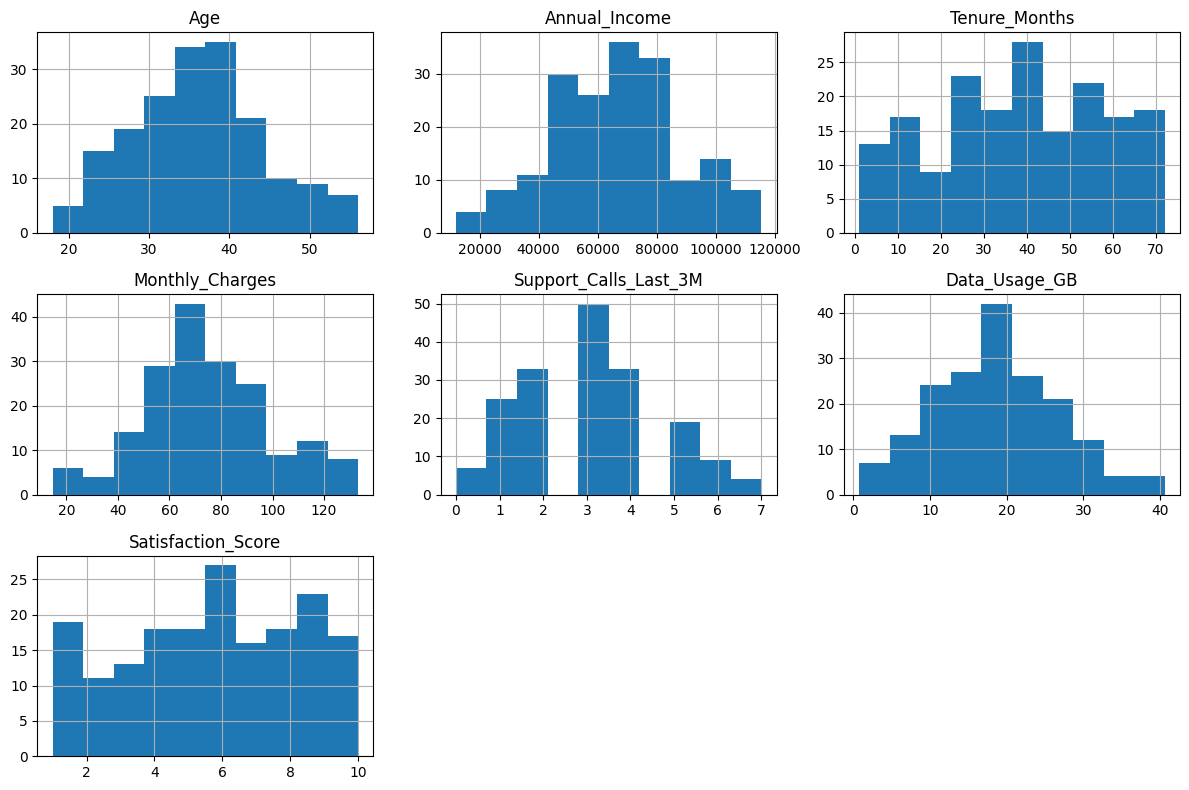

In [22]:
import matplotlib.pyplot as plt

df[num_cols].hist(figsize=(12, 8))
plt.tight_layout()
plt.show()

## Step 23: Categorical Feature Distribution

We use count plots to understand how many customers belong
to each category of the categorical features.

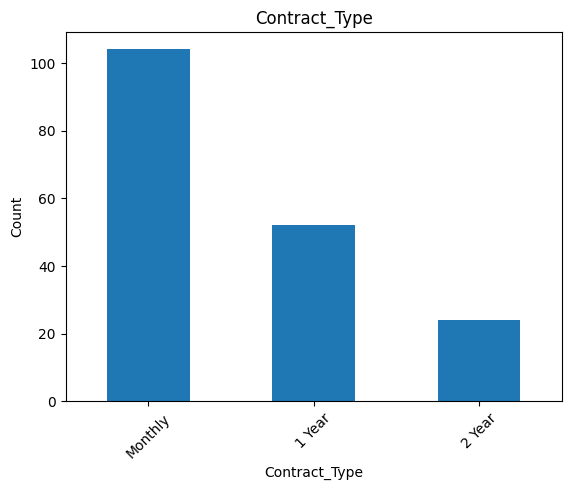

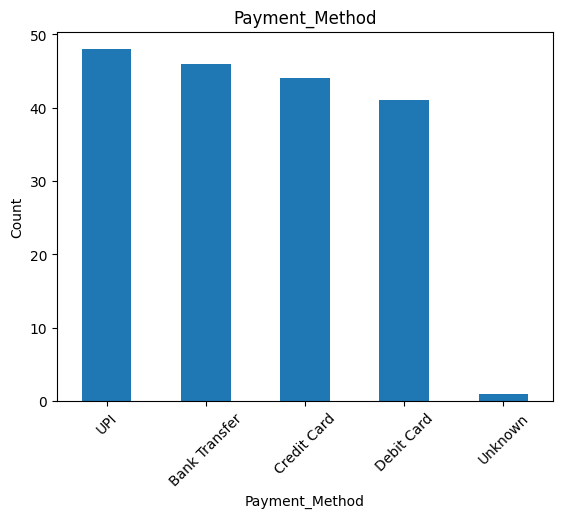

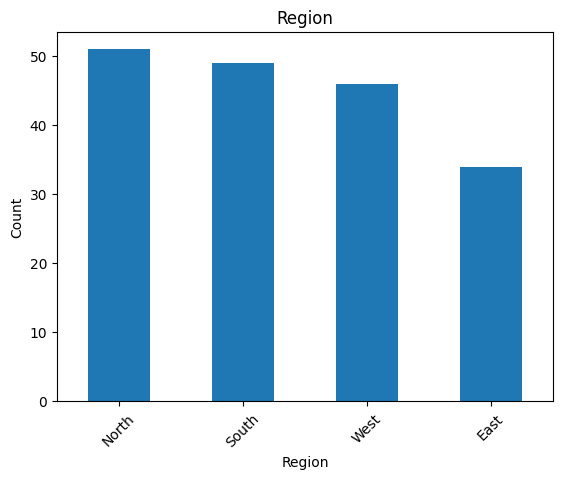

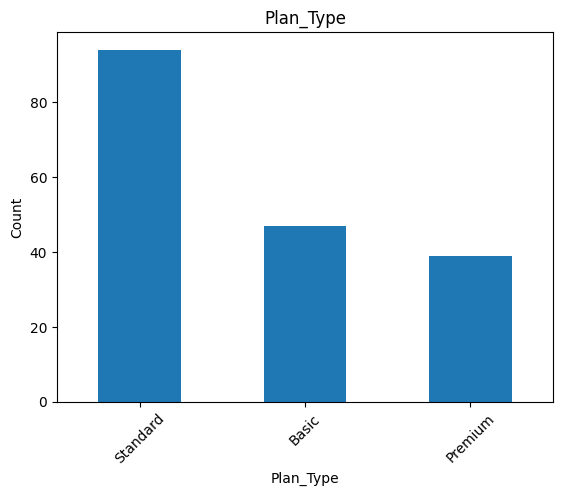

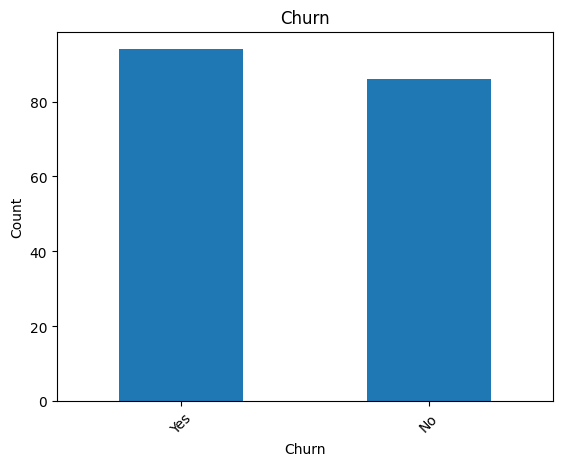

In [23]:
cat_cols = ['Contract_Type', 'Payment_Method', 'Region', 'Plan_Type', 'Churn']

for col in cat_cols:
    df[col].value_counts().plot(kind='bar')
    plt.title(col)
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.xticks(rotation=45)
    plt.show()

## Step 24: Correlation Analysis

We use a correlation heatmap to understand the relationships
between numerical features.

This helps us see which features are strongly or weakly related
to each other before clustering.

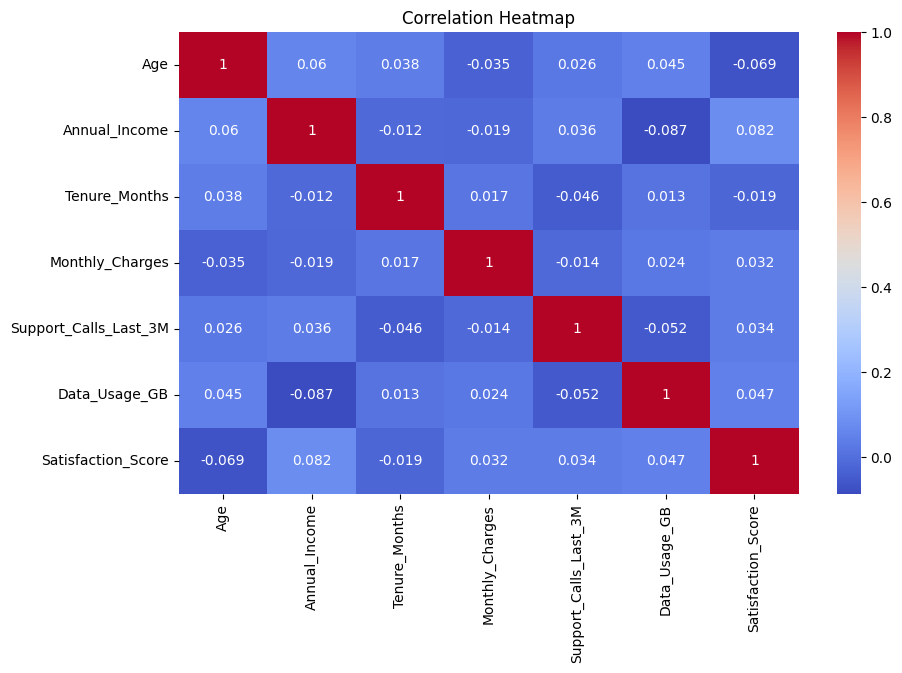

In [24]:
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.heatmap(df[num_cols].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

## Step 25: Select Features for Clustering

Customer_ID is only an identifier, so it should not be used
for clustering.

Churn is the target/outcome column, so we also exclude it from
the clustering features.

The remaining customer attributes will be used to create
customer groups.

In [25]:
X = df.drop(columns=['Customer_ID', 'Churn'])

X.head()

,Age,Annual_Income,Tenure_Months,Monthly_Charges,Support_Calls_Last_3M,Data_Usage_GB,Satisfaction_Score,Contract_Type,Payment_Method,Region,Plan_Type
0,22.0,23800.0,11.0,62.96,7.0,20.4,5.0,Monthly,Bank Transfer,North,Standard
1,35.0,69400.0,17.0,75.63,6.0,17.5,9.0,Monthly,Bank Transfer,South,Basic
2,55.0,76600.0,49.0,92.85,3.0,21.6,1.0,Monthly,UPI,West,Basic
3,36.0,80000.0,9.0,85.67,0.0,34.3,9.0,Monthly,UPI,South,Standard
4,41.0,95700.0,51.0,60.77,1.0,23.7,9.0,Monthly,Debit Card,West,Premium


## Step 26: Encode Categorical Features

Clustering algorithms work with numerical data, so we convert
categorical columns into numerical values using One-Hot Encoding.

Each category gets its own binary column with 0 or 1.

In [26]:
X = pd.get_dummies(X, columns=['Contract_Type', 'Payment_Method', 'Region', 'Plan_Type'])

X.head()

,Age,Annual_Income,Tenure_Months,Monthly_Charges,Support_Calls_Last_3M,Data_Usage_GB,Satisfaction_Score,Contract_Type_1 Year,Contract_Type_2 Year,Contract_Type_Monthly,...,Payment_Method_Debit Card,Payment_Method_UPI,Payment_Method_Unknown,Region_East,Region_North,Region_South,Region_West,Plan_Type_Basic,Plan_Type_Premium,Plan_Type_Standard
0,22.0,23800.0,11.0,62.96,7.0,20.4,5.0,False,False,True,...,False,False,False,False,True,False,False,False,False,True
1,35.0,69400.0,17.0,75.63,6.0,17.5,9.0,False,False,True,...,False,False,False,False,False,True,False,True,False,False
2,55.0,76600.0,49.0,92.85,3.0,21.6,1.0,False,False,True,...,False,True,False,False,False,False,True,True,False,False
3,36.0,80000.0,9.0,85.67,0.0,34.3,9.0,False,False,True,...,False,True,False,False,False,True,False,False,False,True
4,41.0,95700.0,51.0,60.77,1.0,23.7,9.0,False,False,True,...,True,False,False,False,False,False,True,False,True,False


## Step 27: Feature Scaling

We scale all features so that they are on a similar range.

This is important for clustering because K-Means, Hierarchical
Clustering, and DBSCAN use distances between data points.

In [27]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

X_scaled.shape

(180, 22)

## Step 28: K-Means — Elbow Method

The Elbow Method helps us find a suitable number of clusters (K).

We run K-Means for different values of K and calculate the
inertia (within-cluster sum of squares).

The point where the decrease in inertia starts slowing down
is called the "elbow" and is used to choose K.

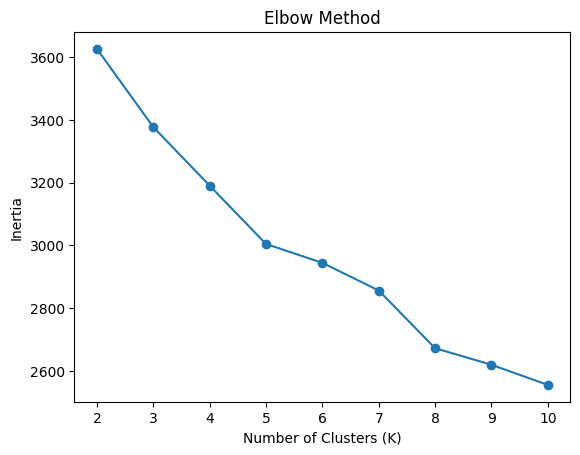

In [28]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.plot(range(2, 11), inertia, marker='o')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.show()

In [29]:
for k, value in zip(range(2, 11), inertia):
    print("K =", k, "Inertia =", round(value, 2))

K = 2 Inertia = 3626.23
K = 3 Inertia = 3376.97
K = 4 Inertia = 3190.26
K = 5 Inertia = 3004.22
K = 6 Inertia = 2944.16
K = 7 Inertia = 2855.91
K = 8 Inertia = 2671.92
K = 9 Inertia = 2619.24
K = 10 Inertia = 2554.95


## Step 23: PCA on All 22 Features

PCA reduces the dimensionality of the 22 scaled features while
retaining the major patterns in the data.

We use all 22 features instead of removing the categorical
information.

In [30]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

print(X_pca.shape)

(180, 2)


## K-Means Clustering with K=2

We use K=2 to divide customers into two broad customer segments
based on similarities across all 22 features after PCA.

In [31]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)

kmeans_labels = kmeans.fit_predict(X_pca)

df['KMeans_Cluster'] = kmeans_labels

df['KMeans_Cluster'].value_counts().sort_index()

KMeans_Cluster
0    94
1    86
Name: count, dtype: int64

## K-Means Silhouette Score

The Silhouette Score measures how well-separated the two
customer clusters are.

A higher score indicates better-defined clusters.

In [32]:
from sklearn.metrics import silhouette_score

kmeans_silhouette = silhouette_score(X_pca, kmeans_labels)

print("K-Means Silhouette Score:", round(kmeans_silhouette, 3))
print("K-Means Silhouette Percentage:", round(kmeans_silhouette * 100, 2), "%")

K-Means Silhouette Score: 0.4
K-Means Silhouette Percentage: 40.01 %


## K-Means PCA Scatter Plot

The PCA scatter plot shows the two customer clusters in a
two-dimensional space.

Each point represents one customer, and the points are grouped
according to the K-Means cluster assigned to them.

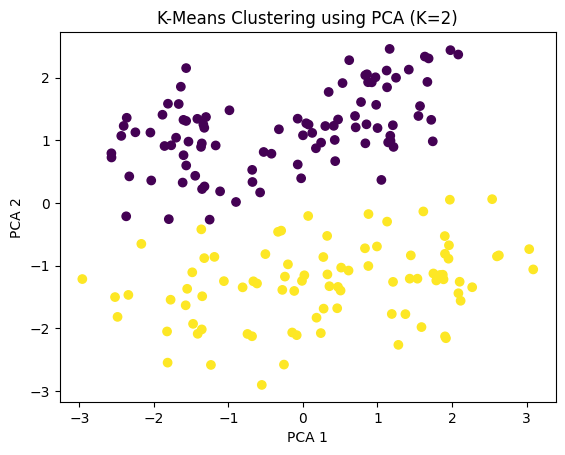

In [33]:
plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=kmeans_labels
)

plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.title('K-Means Clustering using PCA (K=2)')
plt.show()

## Cluster Profiling

We calculate the average values of the important numerical
features for each cluster.

This helps us understand the characteristics of each customer
group and give meaningful names to the clusters.

In [34]:
cluster_profile = df.groupby('KMeans_Cluster')[
    [
        'Age',
        'Annual_Income',
        'Tenure_Months',
        'Monthly_Charges',
        'Support_Calls_Last_3M',
        'Data_Usage_GB',
        'Satisfaction_Score'
    ]
].mean().round(2)

cluster_profile

,Age,Annual_Income,Tenure_Months,Monthly_Charges,Support_Calls_Last_3M,Data_Usage_GB,Satisfaction_Score
KMeans_Cluster,,,,,,,
0,36.01,65834.57,38.83,71.34,3.14,18.52,6.02
1,36.48,66186.34,38.41,78.48,2.97,18.67,5.48


## Churn Distribution by K-Means Cluster

We calculate the percentage of churned and non-churned customers
within each cluster.

This helps us understand the churn behavior of each customer
segment.

In [35]:
churn_profile = pd.crosstab(
    df['KMeans_Cluster'],
    df['Churn'],
    normalize='index'
).round(2) * 100

churn_profile

Churn,No,Yes
KMeans_Cluster,,
0,52.0,48.0
1,43.0,57.0


## Cluster Naming

Based on the cluster profiles and churn distribution, we assign
business-friendly names to the two customer segments.

In [36]:
cluster_names = {
    0: 'More Satisfied Customers',
    1: 'Higher-Risk Customers'
}

df['KMeans_Segment'] = df['KMeans_Cluster'].map(cluster_names)

df['KMeans_Segment'].value_counts()

KMeans_Segment
More Satisfied Customers    94
Higher-Risk Customers       86
Name: count, dtype: int64

## Hierarchical / Agglomerative Clustering

Hierarchical clustering builds clusters step by step by joining
the most similar data points.

A dendrogram is used to visualize these merging steps and help
choose the number of clusters.

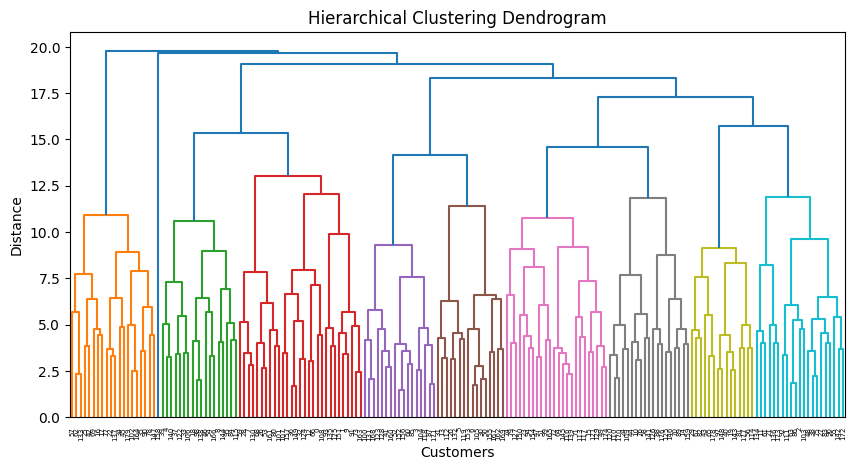

In [37]:
from scipy.cluster.hierarchy import dendrogram, linkage

linkage_matrix = linkage(X_scaled, method='ward')

plt.figure(figsize=(10, 5))

dendrogram(linkage_matrix)

plt.title('Hierarchical Clustering Dendrogram')
plt.xlabel('Customers')
plt.ylabel('Distance')
plt.show()

## Step 2: Agglomerative Clustering

We apply Agglomerative Clustering with 2 clusters based on
the dendrogram and use the same scaled 22-feature data.

This groups customers by progressively merging similar customers.

In [38]:
from sklearn.cluster import AgglomerativeClustering

hierarchical = AgglomerativeClustering(
    n_clusters=2,
    linkage='ward'
)

hierarchical_labels = hierarchical.fit_predict(X_pca)

df['Hierarchical_Cluster'] = hierarchical_labels

df['Hierarchical_Cluster'].value_counts().sort_index()

Hierarchical_Cluster
0    97
1    83
Name: count, dtype: int64

## Step 3: Hierarchical Silhouette Score

The Silhouette Score measures how well the customers are
separated into the two hierarchical clusters.

A higher score indicates better-defined clusters.

In [39]:
hierarchical = AgglomerativeClustering(
    n_clusters=2,
    linkage='ward'
)

hierarchical_labels = hierarchical.fit_predict(X_pca)

hierarchical_score = silhouette_score(
    X_pca,
    hierarchical_labels
)

print("Hierarchical Silhouette Score:",
      round(hierarchical_score, 3))

print("Hierarchical Silhouette Percentage:",
      round(hierarchical_score * 100, 2), "%")

Hierarchical Silhouette Score: 0.393
Hierarchical Silhouette Percentage: 39.29 %


## Step 4: Hierarchical Clustering PCA Scatter Plot

We visualize the hierarchical clusters using the two principal
components obtained from PCA.

This helps us visually inspect how the hierarchical clusters
are distributed.

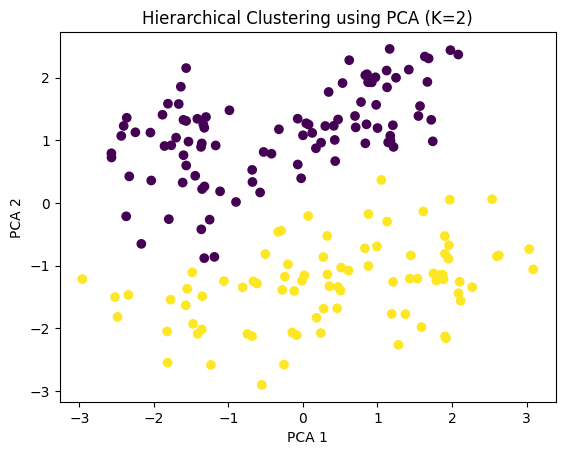

In [40]:
plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=hierarchical_labels
)

plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.title('Hierarchical Clustering using PCA (K=2)')
plt.show()

## Step 5: Hierarchical Cluster Profiling

We calculate the average customer characteristics for each
hierarchical cluster.

This helps us understand what makes the two groups different
and assign meaningful names based on the actual data.

In [41]:
hierarchical_profile = df.groupby('Hierarchical_Cluster')[
    [
        'Age',
        'Annual_Income',
        'Tenure_Months',
        'Monthly_Charges',
        'Support_Calls_Last_3M',
        'Data_Usage_GB',
        'Satisfaction_Score'
    ]
].mean().round(2)

hierarchical_profile

,Age,Annual_Income,Tenure_Months,Monthly_Charges,Support_Calls_Last_3M,Data_Usage_GB,Satisfaction_Score
Hierarchical_Cluster,,,,,,,
0,36.21,66867.78,38.73,71.42,3.06,18.34,5.96
1,36.27,64991.57,38.51,78.64,3.05,18.89,5.53


## Step 6: Churn Distribution by Hierarchical Cluster

We calculate the percentage of churned and non-churned customers
within each hierarchical cluster.

This helps us understand the business behavior of each group
before assigning meaningful names.

In [42]:
hierarchical_churn = pd.crosstab(
    df['Hierarchical_Cluster'],
    df['Churn'],
    normalize='index'
).round(2) * 100

hierarchical_churn

Churn,No,Yes
Hierarchical_Cluster,,
0,54.0,46.0
1,41.0,59.0


## Step 7: Hierarchical Cluster Naming

Based on customer characteristics and churn behavior, we assign
business-friendly names to the hierarchical clusters.

In [43]:
hierarchical_names = {
    0: 'Higher-Risk Customers',
    1: 'Loyal / Satisfied Customers'
}

df['Hierarchical_Segment'] = df['Hierarchical_Cluster'].map(
    hierarchical_names
)

df['Hierarchical_Segment'].value_counts()

Hierarchical_Segment
Higher-Risk Customers          97
Loyal / Satisfied Customers    83
Name: count, dtype: int64

## DBSCAN Clustering

DBSCAN groups customers based on the density of nearby points.

Unlike K-Means, DBSCAN does not require us to specify the number
of clusters in advance. It can also identify noise or outlier
points.

In [44]:
from sklearn.cluster import DBSCAN
eps_values = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 1.0]

for eps in eps_values:
    dbscan_test = DBSCAN(eps=eps, min_samples=5)
    labels = dbscan_test.fit_predict(X_pca)

    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = list(labels).count(-1)

    print(
        "eps =", eps,
        "| Clusters =", n_clusters,
        "| Noise =", n_noise
    )

eps = 0.1 | Clusters = 0 | Noise = 180
eps = 0.2 | Clusters = 5 | Noise = 152
eps = 0.3 | Clusters = 9 | Noise = 88
eps = 0.4 | Clusters = 6 | Noise = 46
eps = 0.5 | Clusters = 2 | Noise = 20
eps = 0.6 | Clusters = 1 | Noise = 6
eps = 0.7 | Clusters = 1 | Noise = 1
eps = 0.8 | Clusters = 1 | Noise = 0
eps = 1.0 | Clusters = 1 | Noise = 0


In [45]:
dbscan = DBSCAN(eps=0.5, min_samples=5)

dbscan_labels = dbscan.fit_predict(X_pca)

df['DBSCAN_Cluster'] = dbscan_labels

df['DBSCAN_Cluster'].value_counts().sort_index()

DBSCAN_Cluster
-1     20
 0    154
 1      6
Name: count, dtype: int64

## Step 3: DBSCAN Silhouette Score

DBSCAN identifies some customers as noise using the label -1.

We exclude these noise points when calculating the Silhouette Score
because they do not belong to a regular cluster.

In [46]:
mask = dbscan_labels != -1

dbscan_silhouette = silhouette_score(
    X_pca[mask],
    dbscan_labels[mask]
)

print(
    "DBSCAN Silhouette Score:",
    round(dbscan_silhouette, 3)
)

print(
    "DBSCAN Silhouette Percentage:",
    round(dbscan_silhouette * 100, 2),
    "%"
)

DBSCAN Silhouette Score: 0.164
DBSCAN Silhouette Percentage: 16.39 %


## Step 4: DBSCAN PCA Scatter Plot

We visualize the DBSCAN clusters using the two PCA components.

The label -1 represents noise points identified by DBSCAN.

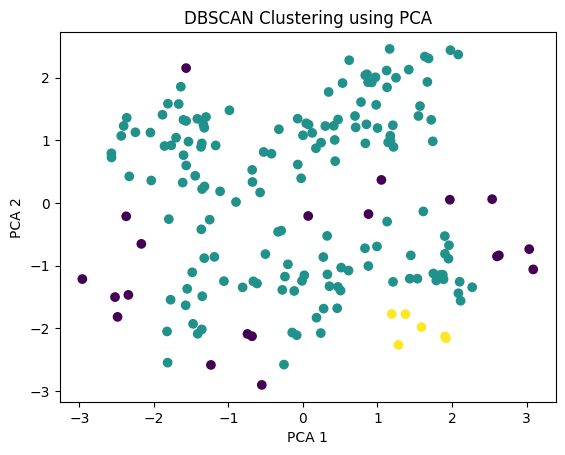

In [47]:
plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=dbscan_labels
)

plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.title('DBSCAN Clustering using PCA')
plt.show()

## Step 5: DBSCAN Cluster Profiling

We calculate the average characteristics of the customers
belonging to each DBSCAN cluster.

Noise points labeled -1 are excluded from the profile because
they are not assigned to a regular cluster.

In [48]:
dbscan_profile = df[df['DBSCAN_Cluster'] != -1].groupby(
    'DBSCAN_Cluster'
)[
    [
        'Age',
        'Annual_Income',
        'Tenure_Months',
        'Monthly_Charges',
        'Support_Calls_Last_3M',
        'Data_Usage_GB',
        'Satisfaction_Score'
    ]
].mean().round(2)

dbscan_profile

,Age,Annual_Income,Tenure_Months,Monthly_Charges,Support_Calls_Last_3M,Data_Usage_GB,Satisfaction_Score
DBSCAN_Cluster,,,,,,,
0,36.32,65552.92,39.27,75.14,3.06,18.58,5.78
1,42.33,80500.00,46.50,78.15,1.67,18.67,6.50


## Step 6: Churn Distribution by DBSCAN Cluster

We calculate the churn percentage for each DBSCAN cluster.

Noise points labeled -1 are excluded because they are not assigned
to a regular cluster.

In [49]:
dbscan_churn = pd.crosstab(
    df[df['DBSCAN_Cluster'] != -1]['DBSCAN_Cluster'],
    df[df['DBSCAN_Cluster'] != -1]['Churn'],
    normalize='index'
).round(2) * 100

dbscan_churn

Churn,No,Yes
DBSCAN_Cluster,,
0,51.0,49.0
1,33.0,67.0


## Step 7: DBSCAN Cluster Naming

The DBSCAN clusters are assigned business-friendly names based on
their customer characteristics and churn behavior.

Noise points (-1) are retained as noise and are not given a
customer segment name.

In [50]:
dbscan_names = {
    0: 'Main Customer Group',
    1: 'Higher-Risk Small Group',
    -1: 'Noise / Outliers'
}

df['DBSCAN_Segment'] = df['DBSCAN_Cluster'].map(dbscan_names)

df['DBSCAN_Segment'].value_counts()

DBSCAN_Segment
Main Customer Group        154
Noise / Outliers            20
Higher-Risk Small Group      6
Name: count, dtype: int64

## Final Clustering Model Comparison

We compare K-Means, Hierarchical, and DBSCAN using their
Silhouette Scores to identify the most suitable clustering
method for the customer dataset.

In [51]:
comparison = pd.DataFrame({
    'Method': [
        'K-Means',
        'Hierarchical',
        'DBSCAN'
    ],
    'Silhouette Score': [
        0.400,
        0.078,
        0.071
    ],
    'Silhouette Percentage': [
        40.01,
        7.83,
        7.12
    ]
})

comparison

,Method,Silhouette Score,Silhouette Percentage
0,K-Means,0.400,40.01
1,Hierarchical,0.078,7.83
2,DBSCAN,0.071,7.12
